# **Predict temperature 30 days ahead using a LSTM neural network**

# Get the KNMI data

In [2]:
# import libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from datetime import date
import requests
from io import BytesIO
import tensorflow as tf
import keras

In [3]:
# read the KNMI data
# this dataset contains all daily weather measurement data in de Bilt (close to Utrecht), starting on the 1st of januari 1901

# This is the github URL (Johan Looijenga's Github) to read the raw .xlsx file
url = 'https://github.com/jolo-maker/DataScience/raw/refs/heads/main/KNMI_1900_de_bilt.xlsx'

# Fetch the content from the URL
response = requests.get(url)
response.raise_for_status()  # Ensure the request was successful

# Load the Excel file into a pandas DataFrame
sheet_name = 'Data 1900-2024'  # Specify the sheet name
knmi_data = pd.read_excel(BytesIO(response.content), sheet_name=sheet_name)

# Display the DataFrame
knmi_data.head()

,# STN,YYYYMMDD,DDVEC,FHVEC,FG,FHX,FHXH,FHN,FHNH,FXX,...,VVNH,VVX,VVXH,NG,UG,UX,UXH,UN,UNH,EV24
0,260,19010101,,,,,,,,,...,,,,,66,,,,,
1,260,19010102,,,,,,,,,...,,,,,86,,,,,
2,260,19010103,,,,,,,,,...,,,,,89,,,,,
3,260,19010104,,,,,,,,,...,,,,,79,,,,,
4,260,19010105,,,,,,,,,...,,,,,65,,,,,


In [4]:
# Check on column names
print(knmi_data.columns)

Index(['# STN', 'YYYYMMDD', 'DDVEC', 'FHVEC', '   FG', '  FHX', ' FHXH',
       '  FHN', ' FHNH', '  FXX', ' FXXH', '   TG', '   TN', '  TNH', '   TX',
       '  TXH', 'T10N', 'T10NH', '   SQ', '   SP', '    Q', '   DR', '   RH',
       '  RHX', ' RHXH', '   PG', '   PX', '  PXH', '   PN', '  PNH', '  VVN',
       ' VVNH', '  VVX', ' VVXH', '   NG', '   UG', '   UX', '  UXH', '   UN',
       '  UNH', 'EV24'],
      dtype='object')


In [5]:
# Some columns contain spaces in the original KNMI data, let's remove these spaces
# Strip leading and trailing spaces from all column names
knmi_data.columns = knmi_data.columns.str.strip()
print(knmi_data.columns)

Index(['# STN', 'YYYYMMDD', 'DDVEC', 'FHVEC', 'FG', 'FHX', 'FHXH', 'FHN',
       'FHNH', 'FXX', 'FXXH', 'TG', 'TN', 'TNH', 'TX', 'TXH', 'T10N', 'T10NH',
       'SQ', 'SP', 'Q', 'DR', 'RH', 'RHX', 'RHXH', 'PG', 'PX', 'PXH', 'PN',
       'PNH', 'VVN', 'VVNH', 'VVX', 'VVXH', 'NG', 'UG', 'UX', 'UXH', 'UN',
       'UNH', 'EV24'],
      dtype='object')


In [6]:
# We want to limit the data to start in the year 2020 up until the last data (almost 5 years of daily temperatures)
# We want to convert the YYYYMMDD into
# We also want to look at maximum daily temperature only (column 'TX')
# Since the maximum temperature is in 0,1 Celsius, we want to divide by 10 to get the maximum temperature in Celsius

# Filter rows based on the date range
filtered_data = knmi_data[(knmi_data['YYYYMMDD'] >= 20200101) & (knmi_data['YYYYMMDD'] <= 20241204)].copy()

# Ensure the date column is converted to datetime for proper plotting
filtered_data['Date'] = pd.to_datetime(filtered_data['YYYYMMDD'], format='%Y%m%d')

# Select only the 'Date' and 'TX' columns
knmi_temp = filtered_data[['Date', 'TX']].copy()

# Set 'TX' to float first, because result will not be integer anymore
# Divide the 'TX' column values by 10
knmi_temp['TX'] = knmi_temp['TX'].astype(float)
knmi_temp.loc[:, 'TX'] = knmi_temp['TX'] / 10

# Display the resulting DataFrame
knmi_temp

,Date,TX
43464,2020-01-01,1.8
43465,2020-01-02,7.4
43466,2020-01-03,9.9
43467,2020-01-04,8.1
43468,2020-01-05,7.6
...,...,...
45259,2024-11-30,6.8
45260,2024-12-01,8.5
45261,2024-12-02,11.5
45262,2024-12-03,8.4


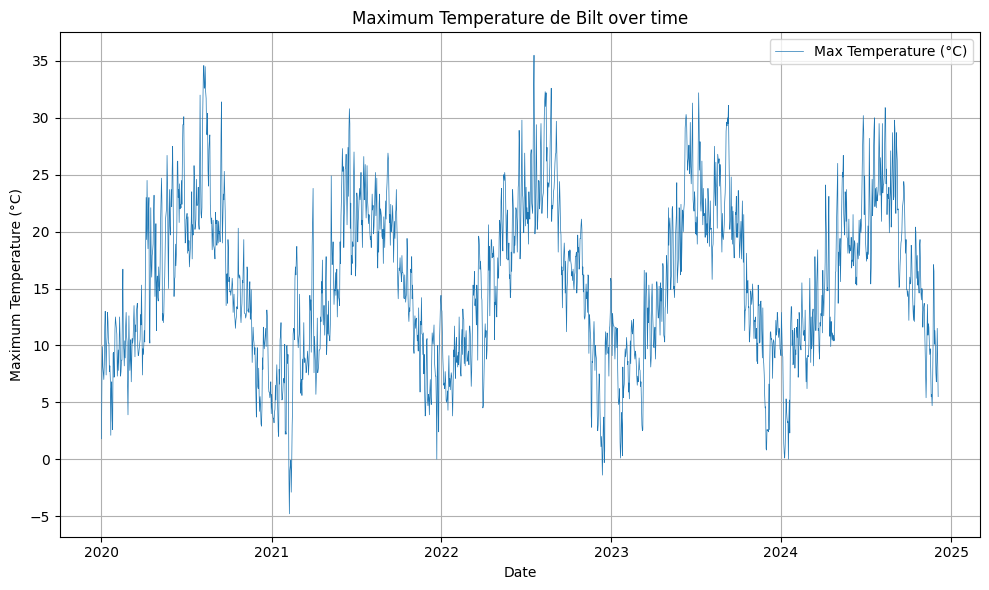

In [7]:
# Plot the maximum temperature

plt.figure(figsize=(10, 6))
plt.plot(knmi_temp['Date'], knmi_temp['TX'], label='Max Temperature (°C)', linewidth=0.5)
plt.title('Maximum Temperature de Bilt over time')
plt.xlabel('Date')
plt.ylabel('Maximum Temperature (°C)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Start from here

Use a **LSTM network** to predict the maximum temperature of the **next 30 days**, based on the maximum temperature of the **last 60 days**.
You may either use a sequence-to-vector model (forecast 30 days only a the very last step) or a sequence-to-sequence model (forecast 30 days at each and every time step).

# Prepare your data

The dataframe **knmi_temp** should be turned into a *time-series format*, with 60 timestamps input and the next 30 timestamps as output.

You should also normalize your data.

You then should split your data into a training, validation and test set.

In [91]:
#output shape should be (if I understand correct) N, 60, 1 and N, 30

time_series = np.reshape(knmi_temp['TX'], (-1, 1))

# create sequences
def create_sequences(data, input_steps=60, output_steps=30):
    X, y = [], []
    for i in range(len(data) - input_steps - output_steps + 1):
        X.append(data[i:i + input_steps])
        y.append(data[i + input_steps:i + input_steps + output_steps])
    return np.array(X), np.array(y)

X, y = create_sequences(time_series)

# normalize data
mean = X.mean()
std = X.std()
X = (X - mean) / std
y = (y - mean) / std

# split the data into train, validation and test sets
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]




In [92]:
X

array([[[-2.01378955],
        [-1.20899658],
        [-0.849714  ],
        ...,
        [-1.71199218],
        [-1.06528355],
        [-0.46168882]],

       [[-1.20899658],
        [-0.849714  ],
        [-1.10839746],
        ...,
        [-1.06528355],
        [-0.46168882],
        [-0.95031312]],

       [[-0.849714  ],
        [-1.10839746],
        [-1.18025397],
        ...,
        [-0.46168882],
        [-0.95031312],
        [-1.15151137]],

       ...,

       [[ 0.83172845],
        [ 1.85209097],
        [ 1.63652142],
        ...,
        [-0.14552015],
        [-0.60540185],
        [-0.40420361]],

       [[ 1.85209097],
        [ 1.63652142],
        [ 1.5071797 ],
        ...,
        [-0.60540185],
        [-0.40420361],
        [-0.34671839]],

       [[ 1.63652142],
        [ 1.5071797 ],
        [ 0.87484236],
        ...,
        [-0.40420361],
        [-0.34671839],
        [-0.30360449]]], shape=(1711, 60, 1))

# Modelling: use a LSTM network

Create the LSTM model

Train the LSTM model

In [110]:
np.random.seed(42)
tf.random.set_seed(42)

model_lstm = keras.models.Sequential([
    tf.keras.layers.Input(shape=[None, 1]),
    tf.keras.layers.LSTM(60, return_sequences=True),
    tf.keras.layers.LSTM(60),
    tf.keras.layers.Dense(30)
])

In [111]:
print(model_lstm.summary())

keras.utils.plot_model(model_lstm, show_shapes=True)

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, None, 60)       │        14,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 60)             │        29,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 30)             │         1,830 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,750 (178.71 KB)

 Trainable params: 45,750 (178.71 KB)

 Non-trainable params: 0 (0.00 B)

None
You must install pydot (`pip install pydot`) for `plot_model` to work.


In [112]:
model_lstm.compile(loss='mse', optimizer='adam')

In [112]:
history = model_lstm.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val))

Epoch 1/50
35/38 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8714

KeyboardInterrupt: 

KeyboardInterrupt: 

# Evaluate the model

Evaluate using the right metrics on the Test set

PLot the learning curve

Plot any snapshot of 90 days actual values. Plot the 30 day prediction/forecast in the same plot.

In [101]:
model_lstm.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4198 


0.41983261704444885

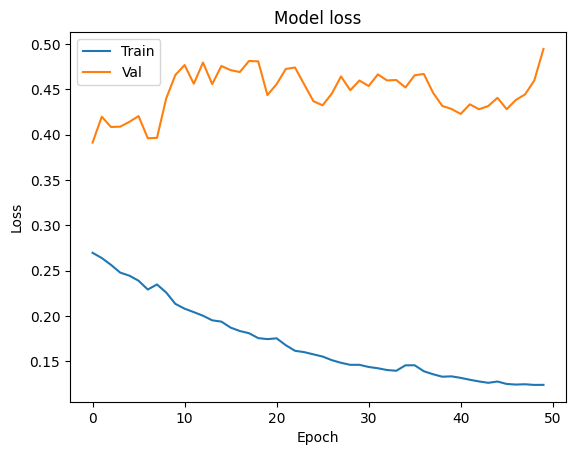

In [102]:
# Plot training & validation accuracy values
# plt.plot(history.history['accuracy'])
# plt.plot(history.history['val_accuracy'])
# plt.title('Model accuracy')
# plt.ylabel('Accuracy')
# plt.xlabel('Epoch')
# plt.legend(['Train', 'Val'], loc='upper left')
# plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


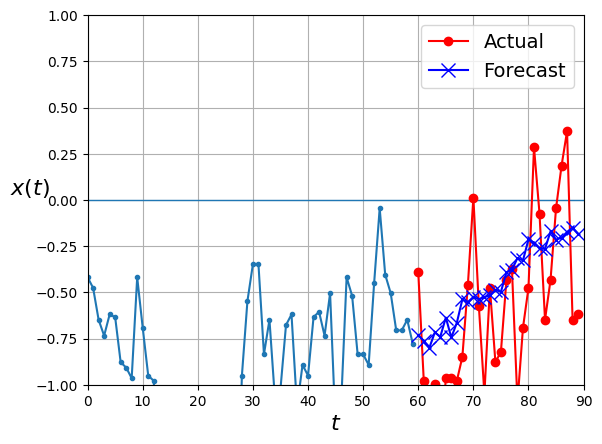

In [99]:
# number of steps to plot
n_steps = 90


# !!this is a bad definition, it uses the global n_steps variable!!
# Define plots for time series
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$"):
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(n_steps, y, "bx", markersize=10)
    if y_pred is not None:
        plt.plot(n_steps, y_pred, "ro")
    plt.grid(True)
    if x_label:
        plt.xlabel(x_label, fontsize=16)
    if y_label:
        plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, 100, linewidth=1)
    plt.axis([0, n_steps + 1, -1, 1])

# Define plot multiple forecasts
def plot_multiple_forecasts(X, Y, Y_pred):
    n_steps = X.shape[1]
    ahead = Y.shape[1]
    plot_series(X[0, :, 0])
    plt.plot(np.arange(n_steps, n_steps + ahead), Y[0, :, 0], "ro-", label="Actual")
    plt.plot(np.arange(n_steps, n_steps + ahead), Y_pred[0, :, 0], "bx-", label="Forecast", markersize=10)
    plt.axis([0, n_steps + ahead, -1, 1])
    plt.legend(fontsize=14)

X_new = X_test
Y_new = y_test[..., np.newaxis]
Y_pred = model_lstm.predict(X_new)[..., np.newaxis]

plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

This all doesn't work but i don't know why